In [52]:
# Cell 0 — Imports
import numpy as np
import matplotlib.pyplot as plt

from itertools import product

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, r2_score, mean_absolute_error

In [53]:
# Cell 1 — Baseline parameters and initial conditions
# ---- Wake curve parameters ----
d_star = 2.0
a      = 0.2
s      = 1.6

# ---- Model / control parameters ----
v_star = 16.0
alpha  = 0.5
beta   = 0.5
K      = 13.0

gamma  = 0.00050625
delta  = 0.01
f_star = 10
Delta_f = 1.3

# Speed bounds
v_min, v_max = 0.0, 25.0

# ---- Number of birds ----
N = 2

# ---- Initial conditions ----
# simple N-bird setup: evenly spaced in x, slight speed gradient, zero initial fatigue
x0 = np.linspace(-(N - 1), (N - 1), N, dtype=float)
v0 = np.linspace(16.2, 16.0, N, dtype=float)
f0 = np.zeros(N, dtype=float)

# optional small symmetry breaking
rng = np.random.default_rng(0)
x0 = x0 + rng.normal(0.0, 0.02, size=N)
v0 = v0 + rng.normal(0.0, 0.01, size=N)

# ---- Simulation settings ----
dt = 0.02
T  = 1200.0
n  = int(T / dt) + 1
t  = np.linspace(0.0, T, n)

print(f"gamma   = {gamma:.8f}")
print(f"f_star  = {f_star:.6f}")
print(f"N       = {N}")
print(f"x0      = {x0}")
print(f"v0      = {v0}")

gamma   = 0.00050625
f_star  = 10.000000
N       = 2
x0      = [-0.9974854  0.9973579]
v0      = [16.20640423 16.001049  ]


In [54]:
# Cell 2 — Model functions, simulator, and baseline simulation
# -------------------------
# Wake function (Lorentzian)
# -------------------------
def wake_lorentzian(d_star, a, s):
    def M(d):
        z = (np.asarray(d) - d_star) / s
        return 1.0 - a / (1.0 + z**2)

    def Mp(d):
        z = (np.asarray(d) - d_star) / s
        return a * (2.0 * z / s) / (1.0 + z**2)**2

    return M, Mp

M, Mp = wake_lorentzian(d_star=d_star, a=a, s=s)

# -------------------------
# Smooth switching weight
# -------------------------
def switching_weight(f, f_star, Delta_f):
    return 1.0 / (1.0 + np.exp(-(f - f_star) / Delta_f))

# -------------------------
# Metrics: switch times, periods, overshoot-from-optimal-spacing, score, validity
# -------------------------
def extract_switch_metrics(t, x, Mi, d_star):
    """
    Definitions:
      - leader(t_k) = argmax_i x[k, i]
      - switch occurs when leader identity changes
      - period = time between consecutive switches
      - overshoot for a switch a->b:
            how much the distance |x_b - x_a| exceeds the optimal spacing d_star
            over the interval [switch_r, switch_{r+1}]
      - score_switch_pair_drag_reduction:
            for each switch old->new, average the drag reduction (1 - Mi)
            of those two birds over [switch_r, switch_{r+1}], then average
            across switch intervals
      - valid = at least 2 switches in timeframe
    """
    n_local, N_local = x.shape
    leaders = np.argmax(x, axis=1)

    switch_indices = []
    switch_times = []
    switch_pairs = []
    for k in range(1, n_local):
        if leaders[k] != leaders[k - 1]:
            switch_indices.append(k)
            switch_times.append(t[k])
            switch_pairs.append((leaders[k - 1], leaders[k]))

    switch_indices = np.array(switch_indices, dtype=int)
    switch_times = np.array(switch_times, dtype=float)

    if len(switch_times) >= 2:
        switch_periods = np.diff(switch_times)
        mean_period = float(np.mean(switch_periods))
    else:
        switch_periods = np.array([], dtype=float)
        mean_period = np.nan

    if len(switch_times) >= 3:
        full_cycle_periods = switch_times[2:] - switch_times[:-2]
        mean_full_cycle_period = float(np.mean(full_cycle_periods))
    elif len(switch_times) >= 2:
        full_cycle_periods = np.array([2.0 * mean_period], dtype=float)
        mean_full_cycle_period = float(2.0 * mean_period)
    else:
        full_cycle_periods = np.array([], dtype=float)
        mean_full_cycle_period = np.nan

    overshoots = []
    if len(switch_indices) >= 2:
        for r in range(len(switch_indices) - 1):
            k0 = switch_indices[r]
            k1 = switch_indices[r + 1]
            old_leader, new_leader = switch_pairs[r]
            d_pair = np.abs(x[k0:k1 + 1, new_leader] - x[k0:k1 + 1, old_leader])
            overshoots.append(float(np.max(np.maximum(d_pair - d_star, 0.0))))
    overshoots = np.array(overshoots, dtype=float)
    mean_overshoot = float(np.mean(overshoots)) if len(overshoots) > 0 else np.nan

    drag_reduction = 1.0 - Mi
    if len(switch_times) >= 2:
        t_start = switch_times[0]
        t_end = switch_times[-1]
        periodic_mask_1d = (t >= t_start) & (t <= t_end)
        score_all = float(np.mean(drag_reduction[periodic_mask_1d, :]))

        follower_mask = np.ones_like(Mi, dtype=bool)
        for k in range(n_local):
            follower_mask[k, leaders[k]] = False
        combined_mask = periodic_mask_1d[:, None] & follower_mask
        score_followers = float(np.mean(drag_reduction[combined_mask])) if np.any(combined_mask) else np.nan

        pair_interval_scores = []
        for r in range(len(switch_indices) - 1):
            k0 = switch_indices[r]
            k1 = switch_indices[r + 1]
            old_leader, new_leader = switch_pairs[r]
            pair_drag = drag_reduction[k0:k1 + 1, [old_leader, new_leader]]
            pair_interval_scores.append(float(np.mean(pair_drag)))
        pair_interval_scores = np.array(pair_interval_scores, dtype=float)
        score_switch_pair = float(np.mean(pair_interval_scores)) if len(pair_interval_scores) > 0 else np.nan
    else:
        t_start = np.nan
        t_end = np.nan
        score_all = np.nan
        score_followers = np.nan
        pair_interval_scores = np.array([], dtype=float)
        score_switch_pair = np.nan

    return {
        "leaders": leaders,
        "switch_indices": switch_indices,
        "switch_times": switch_times,
        "switch_pairs": switch_pairs,
        "switch_periods": switch_periods,
        "mean_period": mean_period,
        "full_cycle_periods": full_cycle_periods,
        "mean_full_cycle_period": mean_full_cycle_period,
        "overshoots": overshoots,
        "mean_overshoot": mean_overshoot,
        "score_all_drag_reduction": score_all,
        "score_follower_drag_reduction": score_followers,
        "score_switch_pair_drag_reduction": score_switch_pair,
        "pair_interval_scores": pair_interval_scores,
        "score_window_start": t_start,
        "score_window_end": t_end,
        "valid": len(switch_times) >= 2,
        "num_switches": len(switch_times),
    }

# -------------------------
# Simulator
# -------------------------
def run_simulation(alpha_val, beta_val, Delta_f_val, f_star_val,
                   d_star_val=d_star, a_val=a, s_val=s,
                   v_star_val=v_star, K_val=K, gamma_val=gamma,
                   delta_val=delta, v_min_val=v_min, v_max_val=v_max,
                   N_val=N, x0_val=None, v0_val=None, f0_val=None,
                   dt_val=dt, T_val=T):
    if x0_val is None:
        x0_val = np.array(x0, dtype=float)
    if v0_val is None:
        v0_val = np.array(v0, dtype=float)
    if f0_val is None:
        f0_val = np.array(f0, dtype=float)

    n_val = int(T_val / dt_val) + 1
    t_val = np.linspace(0.0, T_val, n_val)

    M_local, Mp_local = wake_lorentzian(d_star=d_star_val, a=a_val, s=s_val)

    neighbors = {i: [] for i in range(N_val)}
    for i in range(N_val):
        if i - 1 >= 0:
            neighbors[i].append(i - 1)
        if i + 1 < N_val:
            neighbors[i].append(i + 1)

    def compute_M_and_G(x_now):
        M_out = np.ones(N_val, dtype=float)
        G_out = np.zeros(N_val, dtype=float)
        for i in range(N_val):
            nbrs = neighbors[i]
            if not nbrs:
                M_out[i] = 1.0
                G_out[i] = 0.0
                continue
            d_list = np.array([x_now[j] - x_now[i] for j in nbrs], dtype=float)
            m_list = M_local(d_list)
            mp_list = Mp_local(d_list)
            M_out[i] = 1.0 - float(np.sum(1.0 - m_list))
            G_out[i] = -float(np.sum(mp_list))
        return M_out, G_out

    x_sim = np.zeros((n_val, N_val))
    v_sim = np.zeros((n_val, N_val))
    f_sim = np.zeros((n_val, N_val))
    w_sim = np.zeros((n_val, N_val))
    Mi_sim = np.zeros((n_val, N_val))
    Gi_sim = np.zeros((n_val, N_val))

    x_sim[0, :] = x0_val
    v_sim[0, :] = v0_val
    f_sim[0, :] = f0_val

    for k in range(n_val - 1):
        M_now, G_now = compute_M_and_G(x_sim[k, :])
        Mi_sim[k, :] = M_now
        Gi_sim[k, :] = G_now

        w_now = switching_weight(f_sim[k, :], f_star_val, Delta_f_val)
        w_sim[k, :] = w_now

        x_dot = v_sim[k, :]
        f_dot = gamma_val * M_now * (v_sim[k, :]**2) - delta_val * f_sim[k, :]
        v_dot_cruise = -alpha_val * (v_sim[k, :] - v_star_val)
        v_dot_wake = -beta_val * np.tanh(K_val * G_now)
        v_dot = (1.0 - w_now) * v_dot_cruise + w_now * v_dot_wake

        x_sim[k + 1, :] = x_sim[k, :] + dt_val * x_dot
        f_sim[k + 1, :] = np.maximum(0.0, f_sim[k, :] + dt_val * f_dot)
        v_sim[k + 1, :] = np.clip(v_sim[k, :] + dt_val * v_dot, v_min_val, v_max_val)

    M_last, G_last = compute_M_and_G(x_sim[-1, :])
    Mi_sim[-1, :] = M_last
    Gi_sim[-1, :] = G_last
    w_sim[-1, :] = switching_weight(f_sim[-1, :], f_star_val, Delta_f_val)

    metrics = extract_switch_metrics(t_val, x_sim, Mi_sim, d_star=d_star_val)

    return {
        "t": t_val,
        "x": x_sim,
        "v": v_sim,
        "f": f_sim,
        "w": w_sim,
        "Mi": Mi_sim,
        "Gi": Gi_sim,
        "metrics": metrics,
    }

baseline_run = run_simulation(alpha, beta, Delta_f, f_star)

t = baseline_run["t"]
x = baseline_run["x"]
v = baseline_run["v"]
f = baseline_run["f"]
w = baseline_run["w"]
Mi = baseline_run["Mi"]
Gi = baseline_run["Gi"]
metrics = baseline_run["metrics"]

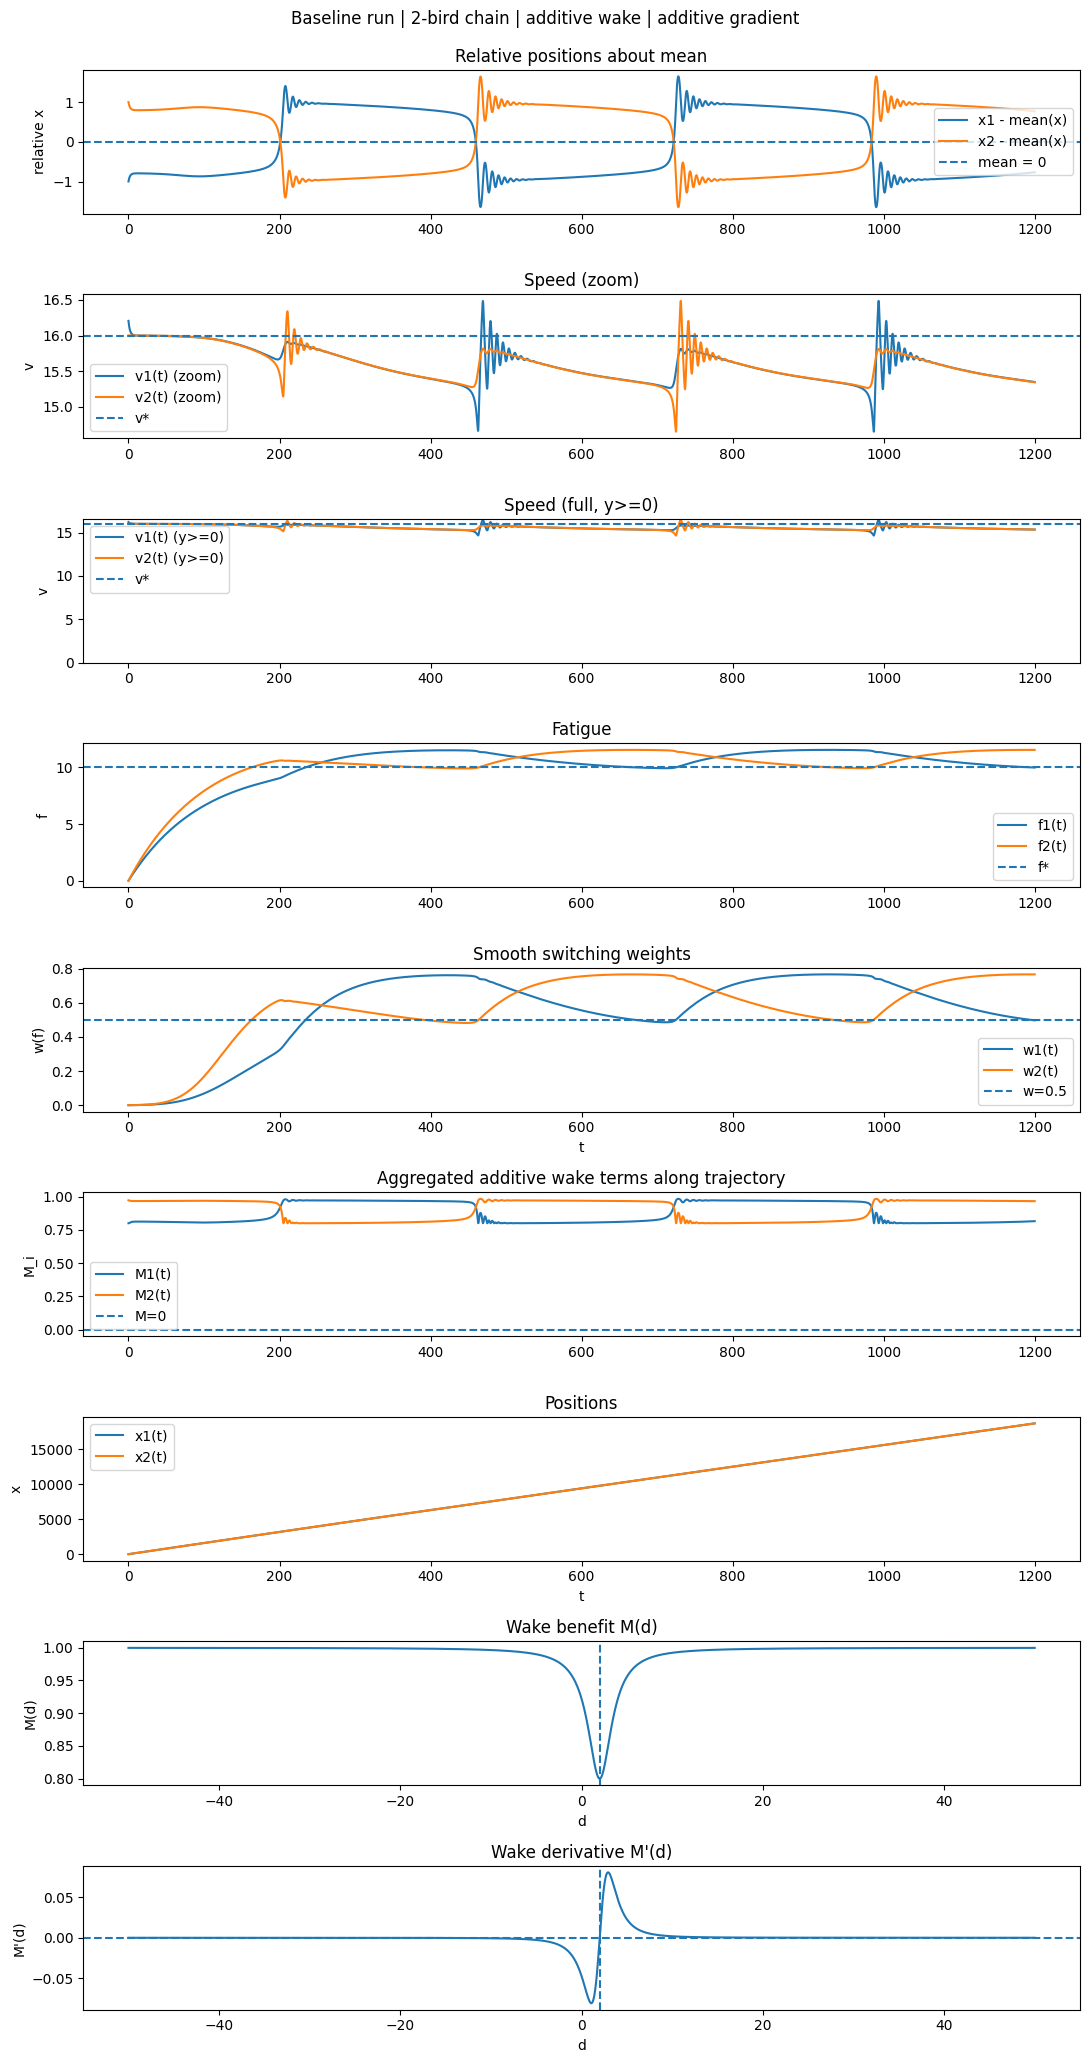

===== Baseline switching metrics =====
valid: True
num_switches: 4
Switch times:
[201.08 459.98 721.96 983.96]
Switch pairs (old -> new):
[(1, 0), (0, 1), (1, 0), (0, 1)]
Leader switching periods:
[258.9  261.98 262.  ]
Mean switching period: 260.96
Mean full cycle period: 522.4300000000001
Mean overshoot: 1.1252408586960883
Score window: [201.08, 983.96]
Score (all-bird avg drag reduction): 0.11003159667511972
Score (follower-only avg drag reduction): 0.18809063962441264
Score (switch-pair avg drag reduction): 0.11003160680378199


In [55]:
# Cell 3 — Baseline plots and analysis

dgrid = np.linspace(-50, 50, 2001)

fig, axes = plt.subplots(9, 1, figsize=(11, 21))
fig.suptitle(f"Baseline run | {N}-bird chain | additive wake | additive gradient")

# 0) Relative-to-mean positions
x_mean = np.mean(x, axis=1, keepdims=True)
x_rel = x - x_mean
for i in range(N):
    axes[0].plot(t, x_rel[:, i], label=f"x{i+1} - mean(x)")
axes[0].axhline(0.0, linestyle="--", label="mean = 0")
axes[0].set_title("Relative positions about mean")
axes[0].set_ylabel("relative x")
axes[0].legend(loc="best")

# 1) Speed (zoom)
for i in range(N):
    axes[1].plot(t, v[:, i], label=f"v{i+1}(t) (zoom)")
axes[1].axhline(v_star, linestyle="--", label="v*")
axes[1].set_title("Speed (zoom)")
axes[1].set_ylabel("v")
axes[1].legend(loc="best")

# 2) Speed (full)
for i in range(N):
    axes[2].plot(t, v[:, i], label=f"v{i+1}(t) (y>=0)")
axes[2].axhline(v_star, linestyle="--", label="v*")
axes[2].set_ylim(bottom=0.0)
axes[2].set_title("Speed (full, y>=0)")
axes[2].set_ylabel("v")
axes[2].legend(loc="best")

# 3) Fatigue
for i in range(N):
    axes[3].plot(t, f[:, i], label=f"f{i+1}(t)")
axes[3].axhline(f_star, linestyle="--", label="f*")
axes[3].set_title("Fatigue")
axes[3].set_ylabel("f")
axes[3].legend(loc="best")

# 4) Switching weights
for i in range(N):
    axes[4].plot(t, w[:, i], label=f"w{i+1}(t)")
axes[4].axhline(0.5, linestyle="--", label="w=0.5")
axes[4].set_title("Smooth switching weights")
axes[4].set_ylabel("w(f)")
axes[4].set_xlabel("t")
axes[4].legend(loc="best")

# 5) Wake multipliers
for i in range(N):
    axes[5].plot(t, Mi[:, i], label=f"M{i+1}(t)")
axes[5].axhline(0.0, linestyle="--", label="M=0")
axes[5].set_title("Aggregated additive wake terms along trajectory")
axes[5].set_ylabel("M_i")
axes[5].legend(loc="best")

# 6) Positions
for i in range(N):
    axes[6].plot(t, x[:, i], label=f"x{i+1}(t)")
axes[6].set_title("Positions")
axes[6].set_ylabel("x")
axes[6].set_xlabel("t")
axes[6].legend(loc="best")

# 7) Wake curve M(d)
axes[7].plot(dgrid, M(dgrid))
axes[7].axvline(d_star, linestyle="--")
axes[7].set_title("Wake benefit M(d)")
axes[7].set_ylabel("M(d)")
axes[7].set_xlabel("d")

# 8) Wake derivative M'(d)
axes[8].plot(dgrid, Mp(dgrid))
axes[8].axvline(d_star, linestyle="--")
axes[8].axhline(0.0, linestyle="--")
axes[8].set_title("Wake derivative M'(d)")
axes[8].set_ylabel("M'(d)")
axes[8].set_xlabel("d")

plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()

print("===== Baseline switching metrics =====")
print(f"valid: {metrics['valid']}")
print(f"num_switches: {metrics['num_switches']}")
print("Switch times:")
print(metrics["switch_times"])
print("Switch pairs (old -> new):")
print(metrics["switch_pairs"])
print("Leader switching periods:")
print(metrics["switch_periods"])
print(f"Mean switching period: {metrics['mean_period']}")
print(f"Mean full cycle period: {metrics['mean_full_cycle_period']}")
print(f"Mean overshoot: {metrics['mean_overshoot']}")
print(f"Score window: [{metrics['score_window_start']}, {metrics['score_window_end']}]")
print(f"Score (all-bird avg drag reduction): {metrics['score_all_drag_reduction']}")
print(f"Score (follower-only avg drag reduction): {metrics['score_follower_drag_reduction']}")
print(f"Score (switch-pair avg drag reduction): {metrics['score_switch_pair_drag_reduction']}")

In [56]:
# Reset only ML-workflow variables from previous runs, while keeping Cells 0–3 intact
for _name in list(globals().keys()):
    if _name.startswith("ml_") or _name.startswith("search_") or _name.startswith("iter_") or _name.startswith("hist_"):
        del globals()[_name]

In [ ]:
# Cell 4 — ML workflow settings and reset

# -------------------------
# Master settings block
# -------------------------
ml_random_seed = 20872920
ml_rng = np.random.default_rng(ml_random_seed)

# Parameters to vary
ml_param_names = ["alpha", "beta", "Delta_f", "f_star"]

# Baseline / original values from Cells 1–3
ml_baseline = {
    "alpha": float(alpha),
    "beta": float(beta),
    "Delta_f": float(Delta_f),
    "f_star": float(f_star),
}

# Fixed simulation parameters (kept at baseline)
ml_fixed = {
    "d_star": float(d_star),
    "a": float(a),
    "s": float(s),
    "v_star": float(v_star),
    "K": float(K),
    "delta": float(delta),
    "gamma": float(gamma),
    "v_min": float(v_min),
    "v_max": float(v_max),
    "N": int(N),
    "dt": float(dt),
    "T": float(T),
    "x0": np.array(x0, dtype=float).copy(),
    "v0": np.array(v0, dtype=float).copy(),
    "f0": np.array(f0, dtype=float).copy(),
}

# Search box around current center: [range_lo * center, range_hi * center]
ml_range_lo = 0.80
ml_range_hi = 1.20

# Sampling / dataset growth
ml_initial_samples = 300
ml_new_samples_per_iter = 200
ml_candidate_pool_multiplier = 30
ml_min_valid_for_regression = 25

# Train / validation split
ml_val_fraction = 0.25

# Validity classifier
ml_validity_threshold = 0.70
ml_clf_hidden = (64, 64)
ml_clf_max_iter = 3000
ml_clf_alpha = 1e-4

# Regressor for [period, overshoot, score]
ml_reg_hidden = (96, 96)
ml_reg_max_iter = 3000
ml_reg_alpha = 1e-4

# Objective target / weights
ml_target_period = float(metrics["mean_period"]) if np.isfinite(metrics["mean_period"]) else 300.0
ml_objective_weights = {
    "period": 1.0,
    "overshoot": 1.0,
    "score": 2.0,
}

# Dense search settings
# With four tuned parameters, a literal 100^4 Cartesian grid is too large.
# Use a dense random candidate pool instead.
ml_dense_search_points = 300000
ml_top_k_validate = 10

# Boundary / iteration / convergence control
ml_boundary_frac = 0.1
ml_max_outer_iterations = 5
ml_objective_tol = 1e-3
ml_param_tol = 5e-4

print("ML workflow settings loaded.")
print("Parameters to vary:", ml_param_names)
print("Baseline center:", ml_baseline)
print(f"Search box multipliers: [{ml_range_lo:.2f}x, {ml_range_hi:.2f}x]")
print(f"Dense random search points: {ml_dense_search_points}")
print(f"Max outer iterations: {ml_max_outer_iterations}, objective tol: {ml_objective_tol}, param tol: {ml_param_tol}")
print("Validity classifier method:")
print("  train RF and scaled MLP, compare by validation F1, keep the better one")
print(f"  validity threshold = {ml_validity_threshold:.2f}")

ML workflow settings loaded.
Parameters to vary: ['alpha', 'beta', 'Delta_f', 'f_star']
Baseline center: {'alpha': 0.5, 'beta': 0.5, 'Delta_f': 1.3, 'f_star': 10.0}
Search box multipliers: [0.80x, 1.20x]
Dense random search points: 300000
Max outer iterations: 5, objective tol: 0.001, param tol: 0.0005
Validity classifier method:
  train RF and scaled MLP, compare by validation F1, keep the better one
  validity threshold = 0.70


In [58]:
# Cell 5 — ML helper functions: simulator wrapper, sampling, fitting, dense search
# -------------------------
# Helpers: parameter dict / box conversions
# -------------------------
def ml_vector_to_param_dict(theta_vec):
    return {
        "alpha": float(theta_vec[0]),
        "beta": float(theta_vec[1]),
        "Delta_f": float(theta_vec[2]),
        "f_star": float(theta_vec[3]),
    }


def ml_param_dict_to_vector(param_dict):
    return np.array([param_dict[p] for p in ml_param_names], dtype=float)


def ml_make_box(center_dict, lo_mult, hi_mult):
    lo = {}
    hi = {}
    for p in ml_param_names:
        c = float(center_dict[p])
        lo[p] = lo_mult * c
        hi[p] = hi_mult * c
    return lo, hi


def ml_in_box(theta_vec, box_lo, box_hi):
    for j, p in enumerate(ml_param_names):
        if theta_vec[j] < box_lo[p] or theta_vec[j] > box_hi[p]:
            return False
    return True


def ml_distance_to_boundary_frac(theta_vec, box_lo, box_hi):
    vals = []
    for j, p in enumerate(ml_param_names):
        lo = box_lo[p]
        hi = box_hi[p]
        width = hi - lo
        vals.append(min(theta_vec[j] - lo, hi - theta_vec[j]) / width)
    return float(min(vals))

# -------------------------
# Helpers for classifier probability / naming
# -------------------------
def ml_predict_valid_proba(clf, X):
    if hasattr(clf, "predict_proba"):
        proba = clf.predict_proba(X)
        if proba.ndim == 2 and proba.shape[1] >= 2:
            return proba[:, 1]
    return clf.predict(X).astype(float)


def ml_classifier_name(clf):
    if isinstance(clf, Pipeline):
        if "mlp" in clf.named_steps:
            return "MLPClassifier"
        return "Pipeline"
    return clf.__class__.__name__


def ml_classifier_iter_info(clf):
    if isinstance(clf, Pipeline) and "mlp" in clf.named_steps:
        mlp = clf.named_steps["mlp"]
        return {
            "n_iter": getattr(mlp, "n_iter_", None),
            "max_iter": getattr(mlp, "max_iter", None),
            "loss": getattr(mlp, "loss_", None),
        }
    return {"n_iter": None, "max_iter": None, "loss": None}

# -------------------------
# Simulator wrapper using the same model structure as Cells 1–3
# -------------------------
def ml_run_simulation_and_metrics(param_dict):
    sim = run_simulation(
        alpha_val=float(param_dict["alpha"]),
        beta_val=float(param_dict["beta"]),
        Delta_f_val=float(param_dict["Delta_f"]),
        f_star_val=float(param_dict["f_star"]),
        d_star_val=ml_fixed["d_star"],
        a_val=ml_fixed["a"],
        s_val=ml_fixed["s"],
        v_star_val=ml_fixed["v_star"],
        K_val=ml_fixed["K"],
        gamma_val=ml_fixed["gamma"],
        delta_val=ml_fixed["delta"],
        v_min_val=ml_fixed["v_min"],
        v_max_val=ml_fixed["v_max"],
        N_val=ml_fixed["N"],
        x0_val=ml_fixed["x0"],
        v0_val=ml_fixed["v0"],
        f0_val=ml_fixed["f0"],
        dt_val=ml_fixed["dt"],
        T_val=ml_fixed["T"],
    )
    met = sim["metrics"]
    return {
        "alpha": float(param_dict["alpha"]),
        "beta": float(param_dict["beta"]),
        "Delta_f": float(param_dict["Delta_f"]),
        "f_star": float(param_dict["f_star"]),
        "valid": bool(met["valid"]),
        "period": float(met["mean_period"]) if np.isfinite(met["mean_period"]) else np.nan,
        "overshoot": float(met["mean_overshoot"]) if np.isfinite(met["mean_overshoot"]) else np.nan,
        "score": float(met["score_switch_pair_drag_reduction"]) if np.isfinite(met["score_switch_pair_drag_reduction"]) else np.nan,
        "num_switches": int(met["num_switches"]),
        "switch_times": met["switch_times"],
    }

# -------------------------
# Sampling
# -------------------------
def ml_random_samples_in_box(rng, n_samples, box_lo, box_hi):
    X = np.zeros((n_samples, len(ml_param_names)), dtype=float)
    for j, p in enumerate(ml_param_names):
        X[:, j] = rng.uniform(box_lo[p], box_hi[p], size=n_samples)
    return X


def ml_biased_unexplored_samples(rng, n_new, box_lo, box_hi, X_existing, pool_multiplier=30):
    if X_existing is None or len(X_existing) == 0:
        return ml_random_samples_in_box(rng, n_new, box_lo, box_hi)

    pool_n = max(pool_multiplier * n_new, n_new)
    pool = ml_random_samples_in_box(rng, pool_n, box_lo, box_hi)

    lo_vec = np.array([box_lo[p] for p in ml_param_names], dtype=float)
    hi_vec = np.array([box_hi[p] for p in ml_param_names], dtype=float)
    width_vec = hi_vec - lo_vec

    X_exist_u = (X_existing - lo_vec) / width_vec
    pool_u = (pool - lo_vec) / width_vec

    chosen = []
    chosen_u = []

    for _ in range(n_new):
        if len(pool_u) == 0:
            break

        if len(chosen_u) == 0:
            ref_u = X_exist_u
        else:
            ref_u = np.vstack([X_exist_u, np.array(chosen_u)])

        d2_mat = np.sum((pool_u[:, None, :] - ref_u[None, :, :])**2, axis=2)
        min_d2 = np.min(d2_mat, axis=1)
        total = np.sum(min_d2)

        if total <= 0.0 or not np.isfinite(total):
            idx = int(rng.integers(len(pool_u)))
        else:
            probs = min_d2 / total
            idx = int(rng.choice(len(pool_u), p=probs))

        chosen.append(pool[idx].copy())
        chosen_u.append(pool_u[idx].copy())
        pool = np.delete(pool, idx, axis=0)
        pool_u = np.delete(pool_u, idx, axis=0)

    return np.array(chosen, dtype=float)


def ml_evaluate_parameter_batch(X_batch, progress_prefix=""):
    rows = []
    total = len(X_batch)
    valid_so_far = 0
    for i, theta in enumerate(X_batch, start=1):
        row = ml_run_simulation_and_metrics(ml_vector_to_param_dict(theta))
        rows.append(row)
        if row["valid"]:
            valid_so_far += 1
        if (i == 1) or (i % max(1, total // 8) == 0) or (i == total):
            print(f"{progress_prefix}sample {i}/{total} | valid so far: {valid_so_far}")
    return rows


def ml_rows_to_arrays(rows):
    X = np.array([[r[p] for p in ml_param_names] for r in rows], dtype=float)
    y_valid = np.array([1 if r["valid"] else 0 for r in rows], dtype=int)
    y_reg = np.array([[r["period"], r["overshoot"], r["score"]] for r in rows], dtype=float)
    return X, y_valid, y_reg

# -------------------------
# Model fitting
# -------------------------
def ml_fit_models(rows, rng_seed=7):
    X, y_valid, y_reg = ml_rows_to_arrays(rows)

    X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(
        X,
        y_valid,
        test_size=ml_val_fraction,
        random_state=rng_seed,
        stratify=y_valid if len(np.unique(y_valid)) > 1 else None,
    )

    # RF classifier
    rf_clf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=rng_seed,
    )
    rf_clf.fit(X_train_c, y_train_c)
    rf_prob = ml_predict_valid_proba(rf_clf, X_val_c)
    rf_pred = (rf_prob >= ml_validity_threshold).astype(int)
    rf_acc = accuracy_score(y_val_c, rf_pred)
    rf_f1 = f1_score(y_val_c, rf_pred, zero_division=0)

    # MLP classifier
    mlp_clf = Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=ml_clf_hidden,
            activation="relu",
            alpha=ml_clf_alpha,
            max_iter=ml_clf_max_iter,
            random_state=rng_seed,
            early_stopping=True,
            validation_fraction=0.15,
        )),
    ])
    mlp_clf.fit(X_train_c, y_train_c)
    mlp_prob = ml_predict_valid_proba(mlp_clf, X_val_c)
    mlp_pred = (mlp_prob >= ml_validity_threshold).astype(int)
    mlp_acc = accuracy_score(y_val_c, mlp_pred)
    mlp_f1 = f1_score(y_val_c, mlp_pred, zero_division=0)

    if rf_f1 >= mlp_f1:
        clf = rf_clf
        chosen_acc = rf_acc
        chosen_f1 = rf_f1
    else:
        clf = mlp_clf
        chosen_acc = mlp_acc
        chosen_f1 = mlp_f1

    clf_info = {
        "chosen_model": ml_classifier_name(clf),
        "chosen_accuracy": float(chosen_acc),
        "chosen_f1": float(chosen_f1),
        "rf_accuracy": float(rf_acc),
        "rf_f1": float(rf_f1),
        "mlp_accuracy": float(mlp_acc),
        "mlp_f1": float(mlp_f1),
        "threshold": float(ml_validity_threshold),
        "mlp_iter_info": ml_classifier_iter_info(mlp_clf),
    }

    # regressor on valid runs only
    valid_mask = (y_valid == 1) & np.all(np.isfinite(y_reg), axis=1)
    X_valid = X[valid_mask]
    Y_valid = y_reg[valid_mask]

    reg = None
    reg_summary = None
    reg_y_mean = None
    reg_y_std = None

    if len(X_valid) >= ml_min_valid_for_regression:
        X_train_r, X_val_r, Y_train_r, Y_val_r = train_test_split(
            X_valid,
            Y_valid,
            test_size=ml_val_fraction,
            random_state=rng_seed,
        )

        reg_y_mean = Y_train_r.mean(axis=0)
        reg_y_std = Y_train_r.std(axis=0) + 1e-12
        Y_train_r_scaled = (Y_train_r - reg_y_mean) / reg_y_std

        reg = Pipeline([
            ("scaler", StandardScaler()),
            ("mlp", MLPRegressor(
                hidden_layer_sizes=ml_reg_hidden,
                activation="relu",
                alpha=ml_reg_alpha,
                max_iter=ml_reg_max_iter,
                random_state=rng_seed,
                early_stopping=True,
                validation_fraction=0.15,
            )),
        ])
        reg.fit(X_train_r, Y_train_r_scaled)

        Y_pred_scaled = reg.predict(X_val_r)
        Y_pred = Y_pred_scaled * reg_y_std + reg_y_mean

        reg_summary = {
            "n_valid_trainable": int(len(X_valid)),
            "r2_period": float(r2_score(Y_val_r[:, 0], Y_pred[:, 0])),
            "r2_overshoot": float(r2_score(Y_val_r[:, 1], Y_pred[:, 1])),
            "r2_score": float(r2_score(Y_val_r[:, 2], Y_pred[:, 2])),
            "mae_period": float(mean_absolute_error(Y_val_r[:, 0], Y_pred[:, 0])),
            "mae_overshoot": float(mean_absolute_error(Y_val_r[:, 1], Y_pred[:, 1])),
            "mae_score": float(mean_absolute_error(Y_val_r[:, 2], Y_pred[:, 2])),
        }
    else:
        reg_summary = {
            "n_valid_trainable": int(len(X_valid)),
            "r2_period": np.nan,
            "r2_overshoot": np.nan,
            "r2_score": np.nan,
            "mae_period": np.nan,
            "mae_overshoot": np.nan,
            "mae_score": np.nan,
        }

    return clf, reg, clf_info, reg_summary, reg_y_mean, reg_y_std, X, y_valid, y_reg

# -------------------------
# Objective and dense search helpers
# -------------------------
def ml_true_objective_from_result(res):
    if res is None or (not res.get("valid", False)):
        return np.inf
    return (
        ml_objective_weights["period"] * abs(res["period"] - ml_target_period) / max(ml_target_period, 1e-8)
        + ml_objective_weights["overshoot"] * max(res["overshoot"], 0.0) / max(ml_fixed["d_star"], 1e-8)
        + ml_objective_weights["score"] * (1.0 - res["score"])
    )


def ml_dense_candidate_search(clf, reg, reg_y_mean, reg_y_std, box_lo, box_hi, rng):
    if reg is None:
        return None

    Xcand = ml_random_samples_in_box(rng, ml_dense_search_points, box_lo, box_hi)
    p_valid = ml_predict_valid_proba(clf, Xcand)
    pred_valid = p_valid >= ml_validity_threshold
    if np.count_nonzero(pred_valid) == 0:
        return None

    Xcand_valid = Xcand[pred_valid]
    p_valid_kept = p_valid[pred_valid]

    Y_scaled = reg.predict(Xcand_valid)
    Y = Y_scaled * reg_y_std + reg_y_mean

    pred_period = Y[:, 0]
    pred_overshoot = Y[:, 1]
    pred_score = Y[:, 2]

    period_term = np.abs(pred_period - ml_target_period) / max(ml_target_period, 1e-8)
    overshoot_term = np.maximum(pred_overshoot, 0.0) / max(ml_fixed["d_star"], 1e-8)
    score_term = 1.0 - pred_score

    surrogate_obj = (
        ml_objective_weights["period"] * period_term
        + ml_objective_weights["overshoot"] * overshoot_term
        + ml_objective_weights["score"] * score_term
    )
    surrogate_obj = surrogate_obj + 0.15 * (1.0 - p_valid_kept)

    n_top = min(ml_top_k_validate, len(Xcand_valid))
    top_idx_unsorted = np.argpartition(surrogate_obj, n_top - 1)[:n_top]
    top_order = top_idx_unsorted[np.argsort(surrogate_obj[top_idx_unsorted])]

    return {
        "Xcand_total": int(len(Xcand)),
        "Xcand_pred_valid": int(len(Xcand_valid)),
        "Xcand_valid": Xcand_valid,
        "p_valid_kept": p_valid_kept,
        "pred_period": pred_period,
        "pred_overshoot": pred_overshoot,
        "pred_score": pred_score,
        "surrogate_obj": surrogate_obj,
        "top_order": top_order,
    }

In [59]:
# Cell 6 — Combined ML outer workflow: sample -> fit -> dense search -> validate -> recenter
ml_center = ml_baseline.copy()
ml_box_lo, ml_box_hi = ml_make_box(ml_center, ml_range_lo, ml_range_hi)

hist_rows_all = []
hist_outer = []
ml_best_result = None
ml_prev_best_objective = np.inf
ml_prev_best_theta = None

for outer_it in range(1, ml_max_outer_iterations + 1):
    print("\n" + "=" * 80)
    print(f"Outer iteration {outer_it}/{ml_max_outer_iterations}")
    print("Current center:", ml_center)
    print("Current box:")
    for p in ml_param_names:
        print(f"  {p}: [{ml_box_lo[p]:.6f}, {ml_box_hi[p]:.6f}]")

    # ---------------------------------
    # Build / extend dataset inside current box
    # ---------------------------------
    if outer_it == 1:
        X_new = ml_random_samples_in_box(ml_rng, ml_initial_samples, ml_box_lo, ml_box_hi)
    else:
        if len(hist_rows_all) > 0:
            X_existing_full = np.array([[r[p] for p in ml_param_names] for r in hist_rows_all], dtype=float)
            keep_mask = np.array([ml_in_box(theta, ml_box_lo, ml_box_hi) for theta in X_existing_full], dtype=bool)
            X_existing_in_box = X_existing_full[keep_mask]
        else:
            X_existing_in_box = None
        X_new = ml_biased_unexplored_samples(
            ml_rng,
            ml_new_samples_per_iter,
            ml_box_lo,
            ml_box_hi,
            X_existing_in_box,
            pool_multiplier=ml_candidate_pool_multiplier,
        )

    print(f"Evaluating {len(X_new)} new true simulations ...")
    rows_new = ml_evaluate_parameter_batch(X_new, progress_prefix=f"[iter {outer_it}] ")
    hist_rows_all.extend(rows_new)

    hist_rows_in_box = []
    for r in hist_rows_all:
        theta_r = np.array([r[p] for p in ml_param_names], dtype=float)
        if ml_in_box(theta_r, ml_box_lo, ml_box_hi):
            hist_rows_in_box.append(r)

    X_box, y_valid_box, y_reg_box = ml_rows_to_arrays(hist_rows_in_box)
    n_valid_box = int(np.sum(y_valid_box))
    print(f"Rows in current box: {len(hist_rows_in_box)}")
    print(f"Valid runs in current box: {n_valid_box}")

    # ---------------------------------
    # Fit classifier + regressor
    # ---------------------------------
    clf, reg, clf_info, reg_summary, reg_y_mean, reg_y_std, X_fit, y_valid_fit, y_reg_fit = ml_fit_models(
        hist_rows_in_box,
        rng_seed=ml_random_seed + outer_it,
    )

    print("\nClassifier summary:")
    print(f"  chosen model         = {clf_info['chosen_model']}")
    print(f"  chosen accuracy      = {clf_info['chosen_accuracy']:.4f}")
    print(f"  chosen F1            = {clf_info['chosen_f1']:.4f}")
    print(f"  RF accuracy / F1     = {clf_info['rf_accuracy']:.4f} / {clf_info['rf_f1']:.4f}")
    print(f"  MLP accuracy / F1    = {clf_info['mlp_accuracy']:.4f} / {clf_info['mlp_f1']:.4f}")
    print(f"  validity threshold   = {clf_info['threshold']:.2f}")
    mlp_iter = clf_info["mlp_iter_info"]
    if mlp_iter["n_iter"] is not None:
        print("  MLP training info:")
        print(f"    n_iter_  = {mlp_iter['n_iter']}")
        print(f"    max_iter = {mlp_iter['max_iter']}")
        print(f"    loss_    = {mlp_iter['loss']}")

    print("\nRegressor summary:")
    print(f"  valid trainable runs = {reg_summary['n_valid_trainable']}")
    print(f"  R2 period     = {reg_summary['r2_period']}")
    print(f"  R2 overshoot  = {reg_summary['r2_overshoot']}")
    print(f"  R2 score      = {reg_summary['r2_score']}")
    print(f"  MAE period    = {reg_summary['mae_period']}")
    print(f"  MAE overshoot = {reg_summary['mae_overshoot']}")
    print(f"  MAE score     = {reg_summary['mae_score']}")

    if reg is None:
        print("\nToo few valid runs to train the regression model in this box.")
        break

    # ---------------------------------
    # Dense surrogate search + top-k true validation
    # ---------------------------------
    print("\nRunning dense surrogate candidate search ...")
    search_pack = ml_dense_candidate_search(clf, reg, reg_y_mean, reg_y_std, ml_box_lo, ml_box_hi, ml_rng)
    if search_pack is None:
        print("No predicted-valid candidates found in dense search.")
        break

    Xcand_valid = search_pack["Xcand_valid"]
    p_valid_kept = search_pack["p_valid_kept"]
    pred_period = search_pack["pred_period"]
    pred_overshoot = search_pack["pred_overshoot"]
    pred_score = search_pack["pred_score"]
    surrogate_obj = search_pack["surrogate_obj"]
    top_order = search_pack["top_order"]

    print(f"Predicted-valid dense candidates: {search_pack['Xcand_pred_valid']} / {search_pack['Xcand_total']}")
    print(f"Validating top {len(top_order)} surrogate candidates with true simulator ...")

    top_true_results = []
    for rank, idx in enumerate(top_order, start=1):
        theta = Xcand_valid[idx]
        cand = ml_vector_to_param_dict(theta)
        pred_obj = float(surrogate_obj[idx])
        true_res = ml_run_simulation_and_metrics(cand)
        true_obj = ml_true_objective_from_result(true_res)

        top_true_results.append({
            "rank": rank,
            "params": cand.copy(),
            "pred_valid_prob": float(p_valid_kept[idx]),
            "pred_period": float(pred_period[idx]),
            "pred_overshoot": float(pred_overshoot[idx]),
            "pred_score": float(pred_score[idx]),
            "pred_objective": pred_obj,
            "true_metrics": true_res.copy(),
            "true_objective": float(true_obj),
        })

        print(
            f"[{rank:02d}/{len(top_order)}] "
            f"pred_obj={pred_obj:.6f}, pred_pvalid={p_valid_kept[idx]:.4f} | "
            f"true_valid={true_res['valid']}, true_period={true_res['period']}, "
            f"true_overshoot={true_res['overshoot']}, true_score={true_res['score']}, "
            f"true_obj={true_obj}"
        )

    best_top = min(top_true_results, key=lambda z: z["true_objective"])
    tb = best_top["true_metrics"]

    print("\nBest candidate among top surrogate set after true validation:")
    print(f" surrogate rank = {best_top['rank']}")
    for p in ml_param_names:
        print(f" {p} = {best_top['params'][p]:.6f}")
    print(f" predicted validity prob = {best_top['pred_valid_prob']:.4f}")
    print(f" predicted period = {best_top['pred_period']:.6f}")
    print(f" predicted overshoot = {best_top['pred_overshoot']:.6f}")
    print(f" predicted score = {best_top['pred_score']:.6f}")
    print(f" predicted objective = {best_top['pred_objective']:.6f}")
    print("\nChosen true validated result:")
    print(f" valid = {tb['valid']}")
    print(f" n_switches = {tb['num_switches']}")
    print(f" period = {tb['period']}")
    print(f" overshoot = {tb['overshoot']}")
    print(f" score = {tb['score']}")
    print(f" objective = {best_top['true_objective']}")

    iter_record = {
        "outer_iteration": outer_it,
        "center": ml_center.copy(),
        "box_lo": ml_box_lo.copy(),
        "box_hi": ml_box_hi.copy(),
        "n_rows_in_box": len(hist_rows_in_box),
        "n_valid_in_box": n_valid_box,
        "clf_info": clf_info,
        "reg_summary": reg_summary,
        "best_top": best_top,
        "true_best": tb.copy(),
        "true_objective": float(best_top['true_objective']),
    }
    hist_outer.append(iter_record)

    if ml_best_result is None or best_top["true_objective"] < ml_best_result["objective"]:
        ml_best_result = {
            "outer_iteration": outer_it,
            "params": best_top["params"].copy(),
            "metrics": tb.copy(),
            "objective": float(best_top["true_objective"]),
            "search_result": {
                "selected_from_top_k": int(len(top_order)),
                "selected_rank_among_top_k": int(best_top["rank"]),
                "pred_valid_prob": float(best_top["pred_valid_prob"]),
                "pred_period": float(best_top["pred_period"]),
                "pred_overshoot": float(best_top["pred_overshoot"]),
                "pred_score": float(best_top["pred_score"]),
                "objective_best_pred": float(best_top["pred_objective"]),
                "n_dense_total": int(search_pack["Xcand_total"]),
                "n_dense_pred_valid": int(search_pack["Xcand_pred_valid"]),
            },
        }

    theta_curr = ml_param_dict_to_vector(best_top["params"])
    true_obj = float(best_top["true_objective"])
    objective_improvement = ml_prev_best_objective - true_obj if np.isfinite(ml_prev_best_objective) and np.isfinite(true_obj) else np.inf
    param_step = np.linalg.norm(theta_curr - ml_prev_best_theta) if ml_prev_best_theta is not None else np.inf
    near_boundary = ml_distance_to_boundary_frac(theta_curr, ml_box_lo, ml_box_hi) < ml_boundary_frac

    print("\nStopping / recentering diagnostics:")
    print(f"  near_boundary        = {near_boundary}")
    print(f"  objective_improvement= {objective_improvement}")
    print(f"  parameter_step_norm  = {param_step}")

    converged = (
        np.isfinite(true_obj)
        and np.isfinite(ml_prev_best_objective)
        and objective_improvement >= 0.0
        and objective_improvement < ml_objective_tol
        and param_step < ml_param_tol
    )

    # persist latest fitted models/info to workspace each iteration
    ml_clf = clf
    ml_clf_info = clf_info
    ml_reg = reg
    ml_reg_summary = reg_summary
    ml_reg_y_mean = reg_y_mean
    ml_reg_y_std = reg_y_std

    if converged:
        print("\nConvergence criterion met. Stopping.")
        break

    if not near_boundary:
        print("\nBest true candidate is not near boundary. Stopping.")
        break

    ml_center = best_top["params"].copy()
    ml_box_lo, ml_box_hi = ml_make_box(ml_center, ml_range_lo, ml_range_hi)
    ml_prev_best_objective = true_obj
    ml_prev_best_theta = theta_curr.copy()

# Persist to workspace
ml_hist_rows_all = hist_rows_all
ml_hist_outer = hist_outer

print("\n" + "=" * 80)
print("Workflow complete.")
if ml_best_result is not None:
    print("Best validated result:")
    print(f"  found on outer iteration {ml_best_result['outer_iteration']}")
    print(f"  params  = {ml_best_result['params']}")
    print(f"  metrics = {ml_best_result['metrics']}")
    print(f"  objective = {ml_best_result['objective']}")
else:
    print("No valid best result was found.")


Outer iteration 1/5
Current center: {'alpha': 0.5, 'beta': 0.5, 'Delta_f': 1.3, 'f_star': 10.0}
Current box:
  alpha: [0.400000, 0.600000]
  beta: [0.400000, 0.600000]
  Delta_f: [1.040000, 1.560000]
  f_star: [8.000000, 12.000000]
Evaluating 300 new true simulations ...
[iter 1] sample 1/300 | valid so far: 0
[iter 1] sample 37/300 | valid so far: 23
[iter 1] sample 74/300 | valid so far: 56
[iter 1] sample 111/300 | valid so far: 81
[iter 1] sample 148/300 | valid so far: 110
[iter 1] sample 185/300 | valid so far: 142
[iter 1] sample 222/300 | valid so far: 165
[iter 1] sample 259/300 | valid so far: 189
[iter 1] sample 296/300 | valid so far: 219
[iter 1] sample 300/300 | valid so far: 223
Rows in current box: 300
Valid runs in current box: 223

Classifier summary:
  chosen model         = RandomForestClassifier
  chosen accuracy      = 0.9333
  chosen F1            = 0.9541
  RF accuracy / F1     = 0.9333 / 0.9541
  MLP accuracy / F1    = 0.8667 / 0.9020
  validity threshold   = 

In [60]:
# Cell 7 — Final summary and baseline comparison
print("=" * 80)
print("Final ML search summary")

ml_baseline_true = ml_run_simulation_and_metrics(ml_baseline)
ml_baseline_obj = ml_true_objective_from_result(ml_baseline_true)

print("\nBaseline parameters:")
print(ml_baseline)
print("\nBaseline true metrics:")
print(ml_baseline_true)
print(f"Baseline objective: {ml_baseline_obj}")

if ml_best_result is not None:
    print("\nBest validated parameters:")
    print(ml_best_result["params"])
    print("\nBest validated metrics:")
    print(ml_best_result["metrics"])
    print(f"Best objective: {ml_best_result['objective']}")

    print("\nImprovement relative to baseline:")
    print(f"  objective improvement = {ml_baseline_obj - ml_best_result['objective']}")
    if np.isfinite(ml_baseline_true['period']) and np.isfinite(ml_best_result['metrics']['period']):
        print(f"  period change         = {ml_best_result['metrics']['period'] - ml_baseline_true['period']}")
    if np.isfinite(ml_baseline_true['overshoot']) and np.isfinite(ml_best_result['metrics']['overshoot']):
        print(f"  overshoot change      = {ml_best_result['metrics']['overshoot'] - ml_baseline_true['overshoot']}")
    if np.isfinite(ml_baseline_true['score']) and np.isfinite(ml_best_result['metrics']['score']):
        print(f"  score change          = {ml_best_result['metrics']['score'] - ml_baseline_true['score']}")
else:
    print("\nNo validated best result available.")

print("\nOuter iteration history:")
for rec in ml_hist_outer:
    tb = rec["true_best"]
    ci = rec.get("clf_info", {})
    print(
        f"iter {rec['outer_iteration']}: "
        f"rows={rec['n_rows_in_box']}, "
        f"valid={rec['n_valid_in_box']}, "
        f"clf_model={ci.get('chosen_model', None)}, "
        f"clf_f1={ci.get('chosen_f1', None)}, "
        f"true_valid={tb['valid']}, "
        f"true_period={tb['period']}, "
        f"true_overshoot={tb['overshoot']}, "
        f"true_score={tb['score']}, "
        f"true_obj={rec['true_objective']}"
    )

Final ML search summary

Baseline parameters:
{'alpha': 0.5, 'beta': 0.5, 'Delta_f': 1.3, 'f_star': 10.0}

Baseline true metrics:
{'alpha': 0.5, 'beta': 0.5, 'Delta_f': 1.3, 'f_star': 10.0, 'valid': True, 'period': 260.96, 'overshoot': 1.1252408586960883, 'score': 0.11003160680378199, 'num_switches': 4, 'switch_times': array([201.08, 459.98, 721.96, 983.96])}
Baseline objective: 2.34255721574048

Best validated parameters:
{'alpha': 0.6840580401394964, 'beta': 0.431524308295108, 'Delta_f': 1.1160661471204274, 'f_star': 13.540980742523608}

Best validated metrics:
{'alpha': 0.6840580401394964, 'beta': 0.431524308295108, 'Delta_f': 1.1160661471204274, 'f_star': 13.540980742523608, 'valid': True, 'period': 260.14000000000004, 'overshoot': 0.0, 'score': 0.10655130796447491, 'num_switches': 4, 'switch_times': array([ 312.3 ,  576.48,  834.74, 1092.72])}
Best objective: 1.7900396280931223

Improvement relative to baseline:
  objective improvement = 0.5525175876473576
  period change         

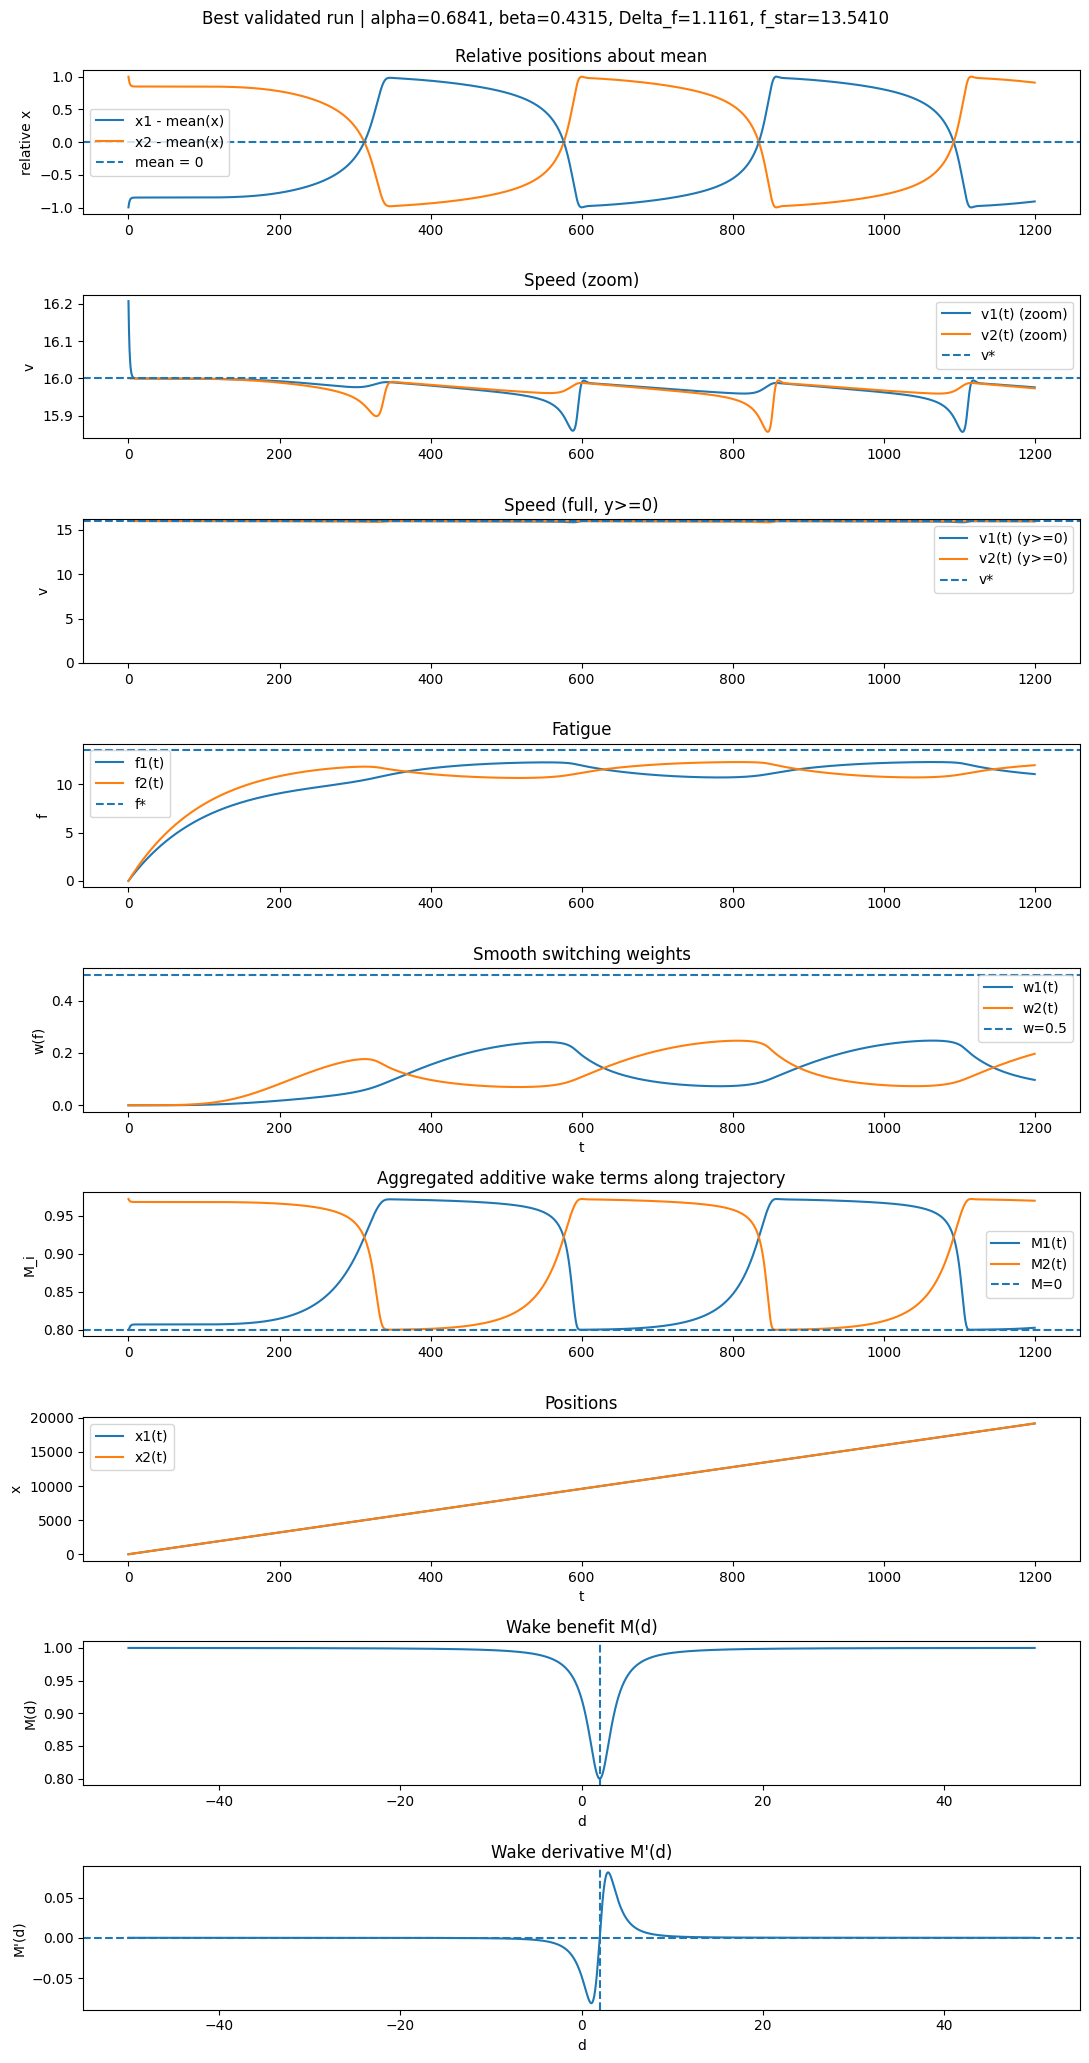


Best-run metrics:
  valid: True
  num_switches: 4
  mean_period: 260.14000000000004
  mean_full_cycle_period: 519.34
  mean_overshoot: 0.0
  switch-pair score: 0.10655130796447491


In [61]:
# Cell 8 — Plot best validated parameter set in the same style as the baseline plot
if ml_best_result is None:
    print("No validated best result available to plot.")
else:
    best_params = ml_best_result["params"]
    best_run = run_simulation(
        alpha_val=best_params["alpha"],
        beta_val=best_params["beta"],
        Delta_f_val=best_params["Delta_f"],
        f_star_val=best_params["f_star"],
    )

    t_best = best_run["t"]
    x_best = best_run["x"]
    v_best = best_run["v"]
    f_best = best_run["f"]
    w_best = best_run["w"]
    Mi_best = best_run["Mi"]
    metrics_best = best_run["metrics"]

    dgrid = np.linspace(-50, 50, 2001)
    fig, axes = plt.subplots(9, 1, figsize=(11, 21))
    fig.suptitle(
        "Best validated run | "
        f"alpha={best_params['alpha']:.4f}, beta={best_params['beta']:.4f}, "
        f"Delta_f={best_params['Delta_f']:.4f}, f_star={best_params['f_star']:.4f}"
    )

    x_mean_best = np.mean(x_best, axis=1, keepdims=True)
    x_rel_best = x_best - x_mean_best
    for i in range(N):
        axes[0].plot(t_best, x_rel_best[:, i], label=f"x{i+1} - mean(x)")
    axes[0].axhline(0.0, linestyle="--", label="mean = 0")
    axes[0].set_title("Relative positions about mean")
    axes[0].set_ylabel("relative x")
    axes[0].legend(loc="best")

    for i in range(N):
        axes[1].plot(t_best, v_best[:, i], label=f"v{i+1}(t) (zoom)")
    axes[1].axhline(v_star, linestyle="--", label="v*")
    axes[1].set_title("Speed (zoom)")
    axes[1].set_ylabel("v")
    axes[1].legend(loc="best")

    for i in range(N):
        axes[2].plot(t_best, v_best[:, i], label=f"v{i+1}(t) (y>=0)")
    axes[2].axhline(v_star, linestyle="--", label="v*")
    axes[2].set_ylim(bottom=0.0)
    axes[2].set_title("Speed (full, y>=0)")
    axes[2].set_ylabel("v")
    axes[2].legend(loc="best")

    for i in range(N):
        axes[3].plot(t_best, f_best[:, i], label=f"f{i+1}(t)")
    axes[3].axhline(best_params['f_star'], linestyle="--", label="f*")
    axes[3].set_title("Fatigue")
    axes[3].set_ylabel("f")
    axes[3].legend(loc="best")

    for i in range(N):
        axes[4].plot(t_best, w_best[:, i], label=f"w{i+1}(t)")
    axes[4].axhline(0.5, linestyle="--", label="w=0.5")
    axes[4].set_title("Smooth switching weights")
    axes[4].set_ylabel("w(f)")
    axes[4].set_xlabel("t")
    axes[4].legend(loc="best")

    for i in range(N):
        axes[5].plot(t_best, Mi_best[:, i], label=f"M{i+1}(t)")
    axes[5].axhline(0.8, linestyle="--", label="M=0")
    axes[5].set_title("Aggregated additive wake terms along trajectory")
    axes[5].set_ylabel("M_i")
    axes[5].legend(loc="best")

    for i in range(N):
        axes[6].plot(t_best, x_best[:, i], label=f"x{i+1}(t)")
    axes[6].set_title("Positions")
    axes[6].set_ylabel("x")
    axes[6].set_xlabel("t")
    axes[6].legend(loc="best")

    axes[7].plot(dgrid, M(dgrid))
    axes[7].axvline(d_star, linestyle="--")
    axes[7].set_title("Wake benefit M(d)")
    axes[7].set_ylabel("M(d)")
    axes[7].set_xlabel("d")

    axes[8].plot(dgrid, Mp(dgrid))
    axes[8].axvline(d_star, linestyle="--")
    axes[8].axhline(0.0, linestyle="--")
    axes[8].set_title("Wake derivative M'(d)")
    axes[8].set_ylabel("M'(d)")
    axes[8].set_xlabel("d")

    plt.tight_layout(rect=[0, 0, 1, 0.985])
    plt.show()

    print("\nBest-run metrics:")
    print(f"  valid: {metrics_best['valid']}")
    print(f"  num_switches: {metrics_best['num_switches']}")
    print(f"  mean_period: {metrics_best['mean_period']}")
    print(f"  mean_full_cycle_period: {metrics_best['mean_full_cycle_period']}")
    print(f"  mean_overshoot: {metrics_best['mean_overshoot']}")
    print(f"  switch-pair score: {metrics_best['score_switch_pair_drag_reduction']}")